# Univariate Normal (Gaussian) Density Function

The **Normal** or **Gaussian** distribution is the most commonly used PDF on a continuous random variable $x$.

$$p(x) = \mathcal{N}(x \mid \mu, \sigma) = \frac{1}{\sqrt{2\pi}\,\sigma} \exp\!\left(-\frac{(x-\mu)^2}{2\sigma^2}\right)$$

| Parameter | Meaning |
|---|---|
| $\mu$ | Mean $= E[x]$ — location of the peak |
| $\sigma$ | Standard deviation — controls the **width** of the bell curve |
| $\sigma^2$ | Variance $= E[(x-\mu)^2]$ |

**Properties:**
- **Unimodal** — single peak at $x = \mu$
- **Symmetric** about $\mu$
- **Standard normal**: $\mu=0,\;\sigma=1$
- Normalised: $\displaystyle\int_{-\infty}^{\infty} p(x)\,dx = 1$

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import norm
from scipy.integrate import quad

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f8f9fa',
    'axes.grid':        True,
    'grid.alpha':       0.35,
    'font.size':        11,
})

## The PDF Formula — Manual Implementation and Verification

We implement the formula by hand and verify it matches `scipy.stats.norm`.

N(μ=170.0, σ=10.0) — PDF values at selected points:



,x,p(x) manual,p(x) scipy,match
0,150.0,0.005399,0.005399,True
1,160.0,0.024197,0.024197,True
2,170.0,0.039894,0.039894,True
3,180.0,0.024197,0.024197,True
4,190.0,0.005399,0.005399,True



∫ p(x) dx  =  1.00000000  (should be 1.0)


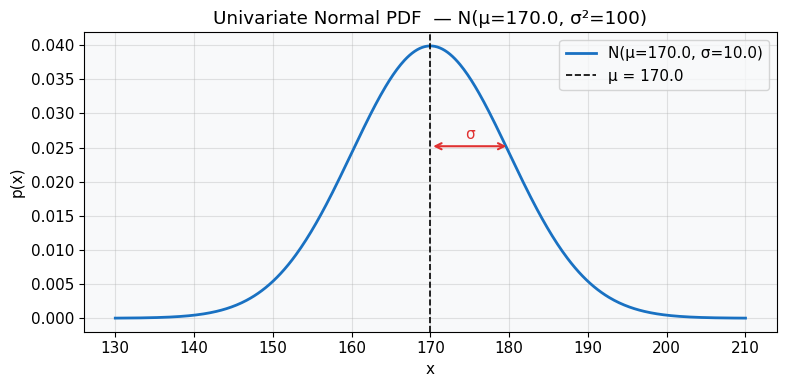

In [6]:
def gaussian_pdf(x, mu, sigma):
    """Manual implementation of the Normal PDF."""
    return (1 / (np.sqrt(2 * np.pi) * sigma)) * np.exp(-((x - mu)**2) / (2 * sigma**2))

# --- Example: height ~ N(170, 10²) ---
mu, sigma = 170.0, 10.0
x_vals = np.linspace(mu - 4*sigma, mu + 4*sigma, 500)

pdf_manual = gaussian_pdf(x_vals, mu, sigma)
pdf_scipy  = norm.pdf(x_vals, loc=mu, scale=sigma)

# Verify at a few sample points
x_test = np.array([150, 160, 170, 180, 190], dtype=float)
df_verify = pd.DataFrame({
    'x': x_test,
    'p(x) manual':  gaussian_pdf(x_test, mu, sigma).round(6),
    'p(x) scipy':   norm.pdf(x_test, loc=mu, scale=sigma).round(6),
    'match':        np.isclose(gaussian_pdf(x_test, mu, sigma),
                               norm.pdf(x_test, loc=mu, scale=sigma)),
})
print(f"N(μ={mu}, σ={sigma}) — PDF values at selected points:\n")
display(df_verify)

# Verify normalisation: ∫p(x)dx = 1
integral, _ = quad(gaussian_pdf, mu - 8*sigma, mu + 8*sigma, args=(mu, sigma))
print(f"\n∫ p(x) dx  =  {integral:.8f}  (should be 1.0)")

# Plot
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x_vals, pdf_manual, color='#1971c2', lw=2, label=f'N(μ={mu}, σ={sigma})')
ax.axvline(mu, color='black', ls='--', lw=1.2, label=f'μ = {mu}')
ax.annotate('', xy=(mu + sigma, gaussian_pdf(mu + sigma, mu, sigma) + 0.001),
            xytext=(mu, gaussian_pdf(mu + sigma, mu, sigma) + 0.001),
            arrowprops=dict(arrowstyle='<->', color='#e03131', lw=1.5))
ax.text(mu + sigma/2, gaussian_pdf(mu + sigma, mu, sigma) + 0.002, 'σ',
        ha='center', color='#e03131', fontsize=11)
ax.set_xlabel('x')
ax.set_ylabel('p(x)')
ax.set_title(f'Univariate Normal PDF  — N(μ={mu}, σ²={sigma**2:.0f})')
ax.legend()
plt.tight_layout()
plt.show()

## Effect of σ on the Bell Curve

$\sigma$ controls the **width** of the bell:
- Small $\sigma$ → tall, narrow peak (low spread)
- Large $\sigma$ → short, wide curve (high spread)

All curves share $\mu = 0$ and integrate to 1.

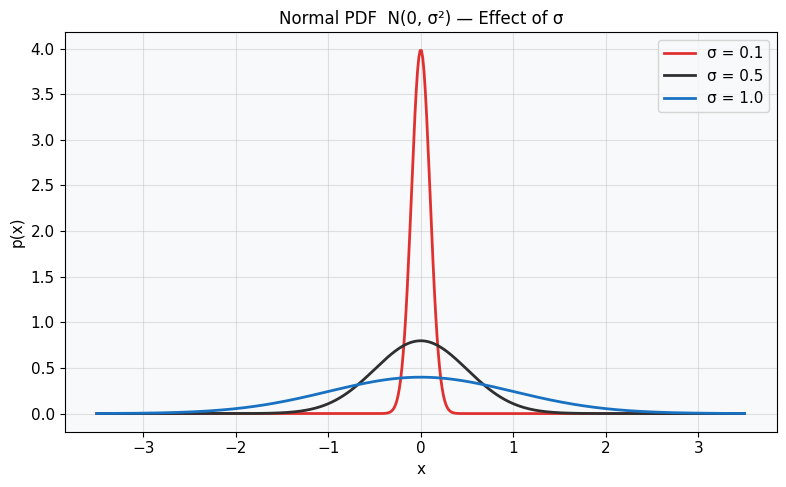


Key values for each σ:


,σ,σ²,Peak p(μ)
0,0.1,0.01,3.9894
1,0.5,0.25,0.7979
2,1.0,1.00,0.3989


In [7]:
sigmas = [0.1, 0.5, 1.0]
colors_sig = ['#e03131', '#2f2f2f', '#1971c2']
x = np.linspace(-3.5, 3.5, 500)

fig, ax = plt.subplots(figsize=(8, 5))
for sigma_i, col in zip(sigmas, colors_sig):
    ax.plot(x, norm.pdf(x, 0, sigma_i), color=col, lw=2,
            label=f'σ = {sigma_i}')

ax.set_xlabel('x')
ax.set_ylabel('p(x)')
ax.set_title('Normal PDF  N(0, σ²) — Effect of σ', fontsize=12)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

# Table: peak heights and σ values
df_sigma = pd.DataFrame([
    {'σ': s, 'σ²': s**2, 'Peak  p(μ)': 1/(np.sqrt(2*np.pi)*s)}
    for s in sigmas
]).round(4)
print("\nKey values for each σ:")
display(df_sigma)

## Probability within σ Bands (68-95-99.7 Rule)

For $\mathcal{N}(\mu, \sigma^2)$:

| Range | Probability |
|---|---|
| $\mu \pm \sigma$ | ≈ **0.6827** (68%) |
| $\mu \pm 2\sigma$ | ≈ **0.9545** (95%) |
| $\mu \pm 3\sigma$ | ≈ **0.9973** (99.7%) |

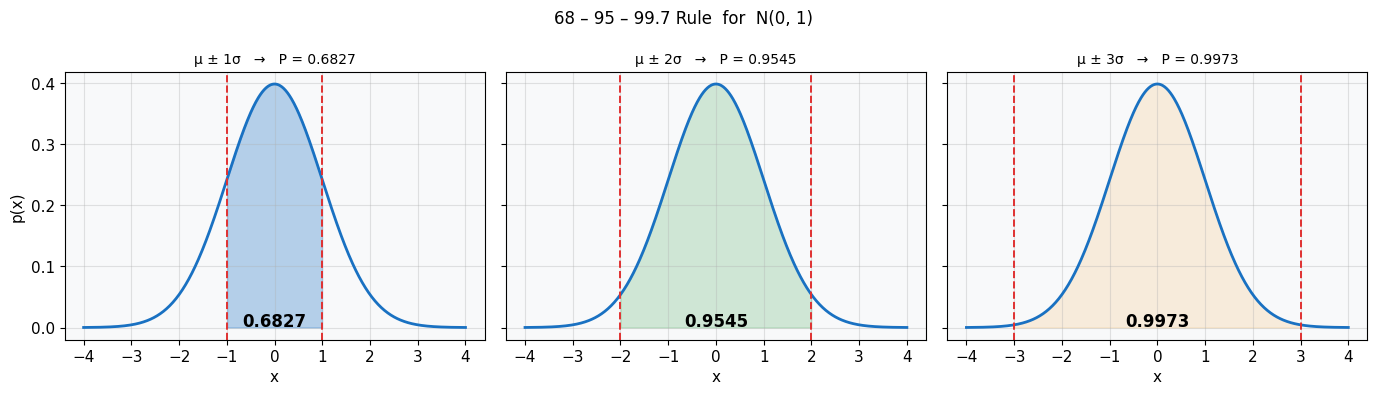

,Band,Lower,Upper,P(lower ≤ x ≤ upper)
0,μ ± 1σ,-1.0,1.0,0.682689
1,μ ± 2σ,-2.0,2.0,0.954500
2,μ ± 3σ,-3.0,3.0,0.997300


In [8]:
mu0, sigma0 = 0.0, 1.0   # standard normal for illustration
x = np.linspace(-4, 4, 600)
pdf = norm.pdf(x, mu0, sigma0)

bands = [
    (1, '#1971c2', 0.30),
    (2, '#2f9e44', 0.20),
    (3, '#f08c00', 0.12),
]

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

for ax, (k, col, alpha) in zip(axes, bands):
    ax.plot(x, pdf, color='#1971c2', lw=2)
    mask = (x >= mu0 - k*sigma0) & (x <= mu0 + k*sigma0)
    ax.fill_between(x, pdf, where=mask, color=col, alpha=alpha)
    prob = norm.cdf(mu0 + k*sigma0) - norm.cdf(mu0 - k*sigma0)
    ax.axvline(mu0 - k*sigma0, color='#e03131', lw=1.4, ls='--')
    ax.axvline(mu0 + k*sigma0, color='#e03131', lw=1.4, ls='--')
    ax.set_title(f'μ ± {k}σ   →   P = {prob:.4f}', fontsize=10)
    ax.set_xlabel('x')
    ax.text(0, 0.05, f'{prob:.4f}', ha='center', fontsize=12,
            color='black', fontweight='bold',
            transform=ax.get_xaxis_transform())

axes[0].set_ylabel('p(x)')
plt.suptitle('68 – 95 – 99.7 Rule  for  N(0, 1)', fontsize=12)
plt.tight_layout()
plt.show()

# Numerical confirmation
df_bands = pd.DataFrame([
    {'Band': f'μ ± {k}σ',
     'Lower': mu0 - k*sigma0,
     'Upper': mu0 + k*sigma0,
     'P(lower ≤ x ≤ upper)': round(norm.cdf(mu0 + k*sigma0) - norm.cdf(mu0 - k*sigma0), 6)}
    for k in [1, 2, 3]
])
display(df_bands)

## Summary

| Property | Value |
|---|---|
| **PDF** | $p(x) = \frac{1}{\sqrt{2\pi}\,\sigma}\exp\!\left(-\frac{(x-\mu)^2}{2\sigma^2}\right)$ |
| **Parameters** | $\mu \in \mathbb{R}$ (mean), $\sigma > 0$ (std dev) |
| **Mean** $E[x]$ | $\mu$ |
| **Variance** $E[(x-\mu)^2]$ | $\sigma^2$ |
| **Mode** (peak) | $x = \mu$ |
| **Normalisation** | $\int_{-\infty}^{\infty} p(x)\,dx = 1$ |
| **Standard normal** | $\mu=0,\;\sigma=1$ |
| **±1σ probability** | 0.6827 |
| **±2σ probability** | 0.9545 |
| **±3σ probability** | 0.9973 |
| **scipy** | `norm.pdf(x, loc=μ, scale=σ)` |